In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from config import (DATA_PROCESSED, MODELS_DIR, FEATURE_COLS_PATH,
                    SCALER_PATH, TEST_SIZE, VAL_SIZE, RANDOM_STATE)
from config import DATA_RAW, DATA_PROCESSED

# Sklearn - preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Sklearn - metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)

# Imbalanced learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports OK")

All imports OK


In [6]:
df = pd.read_csv(DATA_PROCESSED / "cloud_metrics_featured.csv")

print(f"Shape: {df.shape}")
print(f"Anomaly rate: {df['is_anomaly'].mean():.2%}")

# Separate features and target
TARGET = 'is_anomaly'
DROP_COLS = [TARGET]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

feature_columns = list(X.columns)
print(f"Features: {len(feature_columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Shape: (21600, 96)
Anomaly rate: 7.00%
Features: 95
Target distribution:
is_anomaly
0    20089
1     1511
Name: count, dtype: int64


In [7]:
# Verify split is now time-based correctly
df_raw = pd.read_csv(DATA_RAW / "cloud_metrics_historical.csv", 
                     parse_dates=["timestamp"])
df_check = pd.read_csv(DATA_PROCESSED / "cloud_metrics_featured.csv")

n = len(df_check)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

print("=== SPLIT VERIFICATION ===")
print(f"Train resource_id_enc unique: "
      f"{sorted(df_check.iloc[:train_end]['resource_id_enc'].unique())}")
print(f"Val   resource_id_enc unique: "
      f"{sorted(df_check.iloc[train_end:val_end]['resource_id_enc'].unique())}")
print(f"Test  resource_id_enc unique: "
      f"{sorted(df_check.iloc[val_end:]['resource_id_enc'].unique())}")

# Also check timestamps
df_sorted = df_raw.sort_values(["timestamp","resource_id"])
train_ts = df_sorted.iloc[:train_end]['timestamp']
val_ts   = df_sorted.iloc[train_end:val_end]['timestamp']
test_ts  = df_sorted.iloc[val_end:]['timestamp']

print(f"\nTrain timestamps: {train_ts.min().date()} → {train_ts.max().date()}")
print(f"Val   timestamps: {val_ts.min().date()} → {val_ts.max().date()}")
print(f"Test  timestamps: {test_ts.min().date()} → {test_ts.max().date()}")
print(f"\n✓ All splits should show all 10 resources (0-9)")
print(f"✓ Timestamps should be non-overlapping date ranges")

=== SPLIT VERIFICATION ===
Train resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Val   resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test  resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train timestamps: 2026-02-09 → 2026-04-13
Val   timestamps: 2026-04-13 → 2026-04-26
Test  timestamps: 2026-04-26 → 2026-05-10

✓ All splits should show all 10 resources (0-9)
✓ Timestamps should be non-overlapping date ranges


In [8]:
# CRITICAL: time-based split — no shuffle
# Reason: our data has temporal structure (rolling means, lags)
# Random shuffle would leak future information into training data

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print("=" * 45)
print("TRAIN / VAL / TEST SPLIT (time-based)")
print("=" * 45)
print(f"Train : {len(X_train):>6,} rows  anomaly rate: {y_train.mean():.2%}")
print(f"Val   : {len(X_val):>6,} rows  anomaly rate: {y_val.mean():.2%}")
print(f"Test  : {len(X_test):>6,} rows  anomaly rate: {y_test.mean():.2%}")
print(f"Total : {n:>6,} rows")

TRAIN / VAL / TEST SPLIT (time-based)
Train : 15,119 rows  anomaly rate: 6.87%
Val   :  3,241 rows  anomaly rate: 7.25%
Test  :  3,240 rows  anomaly rate: 7.31%
Total : 21,600 rows


In [9]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save scaler immediately
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler saved to: {SCALER_PATH}")

# Save feature columns
with open(FEATURE_COLS_PATH, 'w') as f:
    json.dump(feature_columns, f)
print(f"Feature columns saved to: {FEATURE_COLS_PATH}")
print(f"Scaler mean shape: {scaler.mean_.shape}")

Scaler saved to: D:\B.TECH\Projects\cloud-anomaly-detector\models\scaler.pkl
Feature columns saved to: D:\B.TECH\Projects\cloud-anomaly-detector\models\feature_columns.json
Scaler mean shape: (95,)


In [10]:
# Apply SMOTE only on training set — NEVER on val or test
# Reason: SMOTE creates synthetic rows. Val/test must be real data only.

print(f"Before SMOTE — Train class distribution:")
print(f"  Normal : {(y_train==0).sum():,}")
print(f"  Anomaly: {(y_train==1).sum():,}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE — Train class distribution:")
print(f"  Normal : {(y_train_smote==0).sum():,}")
print(f"  Anomaly: {(y_train_smote==1).sum():,}")
print(f"  Total  : {len(X_train_smote):,}")

Before SMOTE — Train class distribution:
  Normal : 14,080
  Anomaly: 1,039

After SMOTE — Train class distribution:
  Normal : 14,080
  Anomaly: 14,080
  Total  : 28,160


In [11]:
classifiers = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=RANDOM_STATE),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE),

    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=5, use_label_encoder=False,
        eval_metric='logloss', scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=RANDOM_STATE, verbosity=0),

    "KNN": KNeighborsClassifier(
        n_neighbors=7, n_jobs=-1),

    "SVC": SVC(
        kernel='rbf', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE),

    "Gaussian NB": GaussianNB(),
}

print(f"Classifiers defined: {len(classifiers)}")
for name in classifiers:
    print(f"  → {name}")

Classifiers defined: 10
  → Logistic Regression
  → Decision Tree
  → Random Forest
  → Extra Trees
  → Gradient Boosting
  → AdaBoost
  → XGBoost
  → KNN
  → SVC
  → Gaussian NB


In [12]:
mlflow.set_experiment("cloud_anomaly_classification")
print("MLflow experiment set: cloud_anomaly_classification")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow experiment set: cloud_anomaly_classification
MLflow tracking URI: file:///D:/B.TECH/Projects/cloud-anomaly-detector/notebooks/mlruns


In [13]:
results = {}

for name, clf in classifiers.items():
    print(f"Training: {name}...", end=" ")

    with mlflow.start_run(run_name=name):

        # Train on SMOTE data
        clf.fit(X_train_smote, y_train_smote)

        # Predict on val set (real, unsmoted)
        y_pred     = clf.predict(X_val_scaled)
        y_pred_proba = (clf.predict_proba(X_val_scaled)[:, 1]
                        if hasattr(clf, 'predict_proba')
                        else clf.decision_function(X_val_scaled))

        # Metrics
        f1        = f1_score(y_val, y_pred, zero_division=0)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall    = recall_score(y_val, y_pred, zero_division=0)
        roc_auc   = roc_auc_score(y_val, y_pred_proba)
        avg_prec  = average_precision_score(y_val, y_pred_proba)

        # Log to MLflow
        mlflow.log_param("model", name)
        mlflow.log_param("smote", True)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("avg_precision", avg_prec)
        mlflow.sklearn.log_model(clf, name.replace(" ", "_"))

        results[name] = {
            "model"      : clf,
            "f1"         : round(f1, 4),
            "precision"  : round(precision, 4),
            "recall"     : round(recall, 4),
            "roc_auc"    : round(roc_auc, 4),
            "avg_prec"   : round(avg_prec, 4),
            "y_pred"     : y_pred,
            "y_proba"    : y_pred_proba,
        }

        print(f"F1={f1:.3f}  ROC-AUC={roc_auc:.3f}")

print("\nAll models trained!")

Training: Logistic Regression... F1=0.728  ROC-AUC=0.971
Training: Decision Tree... F1=0.795  ROC-AUC=0.927
Training: Random Forest... F1=0.902  ROC-AUC=0.996
Training: Extra Trees... F1=0.862  ROC-AUC=0.992
Training: Gradient Boosting... F1=0.943  ROC-AUC=0.997
Training: AdaBoost... F1=0.868  ROC-AUC=0.989
Training: XGBoost... F1=0.966  ROC-AUC=0.996
Training: KNN... F1=0.476  ROC-AUC=0.876
Training: SVC... F1=0.861  ROC-AUC=0.984
Training: Gaussian NB... F1=0.374  ROC-AUC=0.797

All models trained!


In [14]:
results_df = pd.DataFrame([
    {
        "Model"     : name,
        "F1 Score"  : r["f1"],
        "Precision" : r["precision"],
        "Recall"    : r["recall"],
        "ROC-AUC"   : r["roc_auc"],
        "Avg Prec"  : r["avg_prec"],
    }
    for name, r in results.items()
]).sort_values("F1 Score", ascending=False).reset_index(drop=True)

print("=" * 75)
print("CLASSIFIER BENCHMARK RESULTS (sorted by F1)")
print("=" * 75)
print(results_df.to_string(index=False))

CLASSIFIER BENCHMARK RESULTS (sorted by F1)
              Model  F1 Score  Precision  Recall  ROC-AUC  Avg Prec
            XGBoost    0.9660     0.9660  0.9660   0.9957    0.9856
  Gradient Boosting    0.9435     0.9644  0.9234   0.9969    0.9839
      Random Forest    0.9023     0.9949  0.8255   0.9955    0.9738
           AdaBoost    0.8683     0.8406  0.8979   0.9894    0.9403
        Extra Trees    0.8620     1.0000  0.7574   0.9925    0.9709
                SVC    0.8608     0.8664  0.8553   0.9841    0.9275
      Decision Tree    0.7945     0.7355  0.8638   0.9274    0.7853
Logistic Regression    0.7282     0.6250  0.8723   0.9715    0.8746
                KNN    0.4758     0.3576  0.7106   0.8764    0.5335
        Gaussian NB    0.3741     0.2860  0.5404   0.7971    0.3108


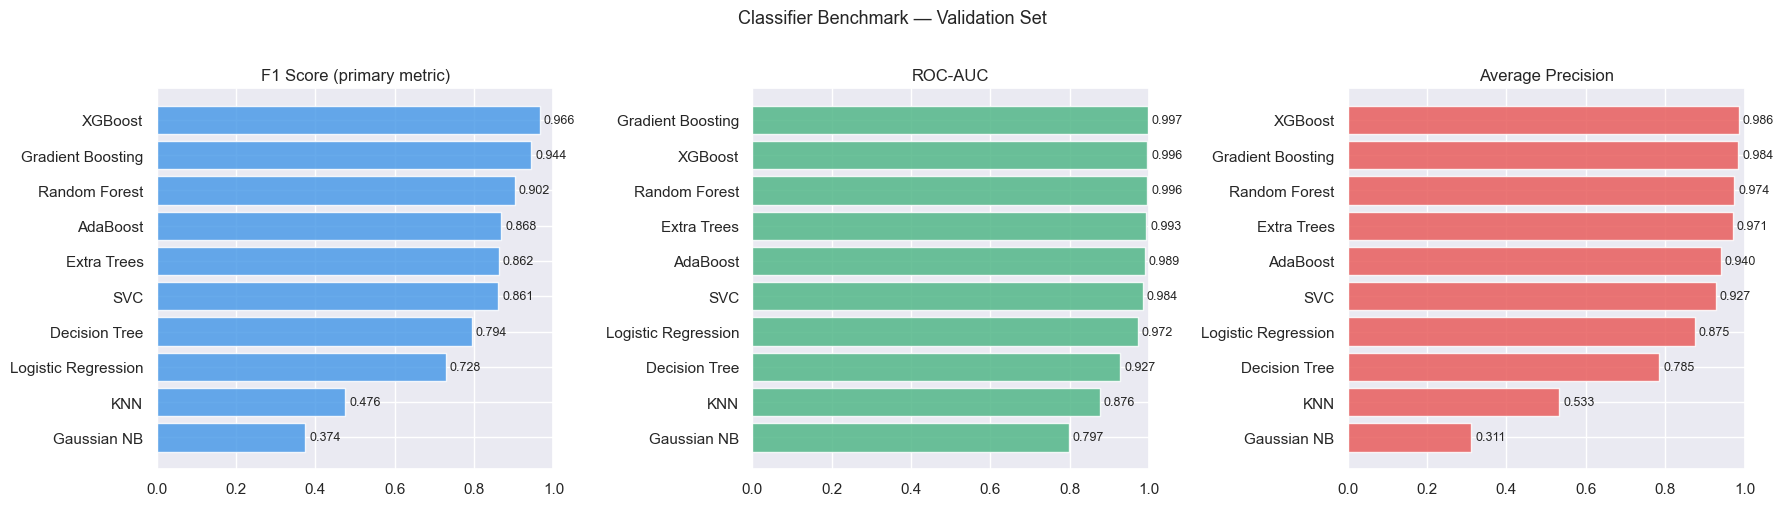

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics   = ["F1 Score", "ROC-AUC", "Avg Prec"]
colors    = ["#4C9BE8", "#52B788", "#E85D5D"]
titles    = ["F1 Score (primary metric)", "ROC-AUC", "Average Precision"]

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    sorted_df = results_df.sort_values(metric, ascending=True)
    axes[i].barh(sorted_df["Model"], sorted_df[metric],
                 color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(title)
    axes[i].set_xlim(0, 1)
    for j, val in enumerate(sorted_df[metric]):
        axes[i].text(val + 0.01, j, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle("Classifier Benchmark — Validation Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

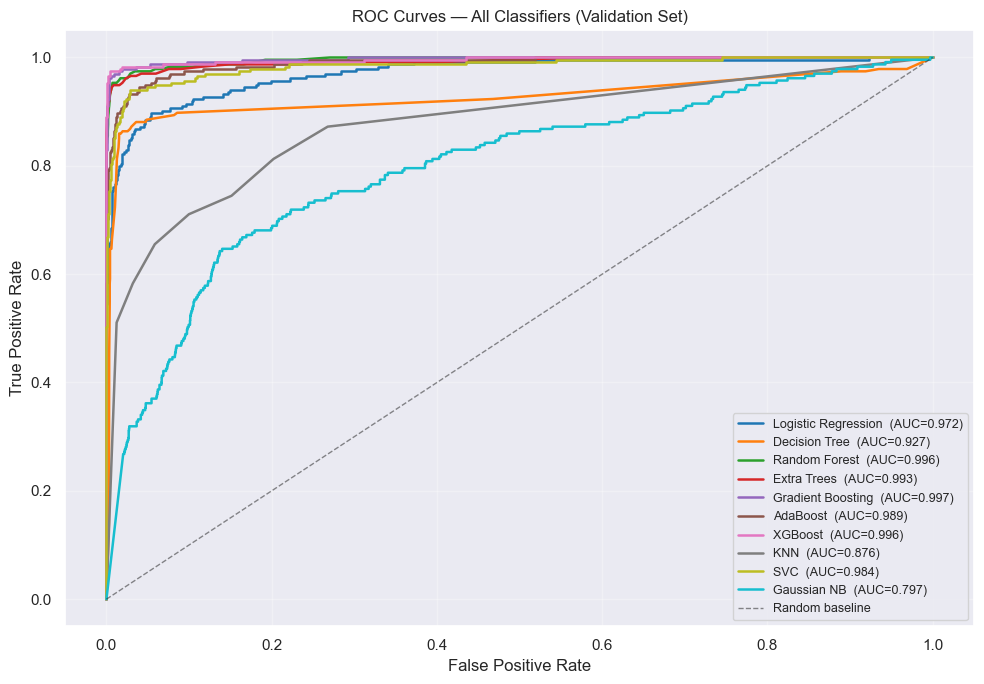

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val, r['y_proba'])
    ax.plot(fpr, tpr, linewidth=1.8, color=color,
            label=f"{name}  (AUC={r['roc_auc']:.3f})")

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_title('ROC Curves — All Classifiers (Validation Set)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best model: XGBoost
F1=0.966  Precision=0.966  Recall=0.966  ROC-AUC=0.9957



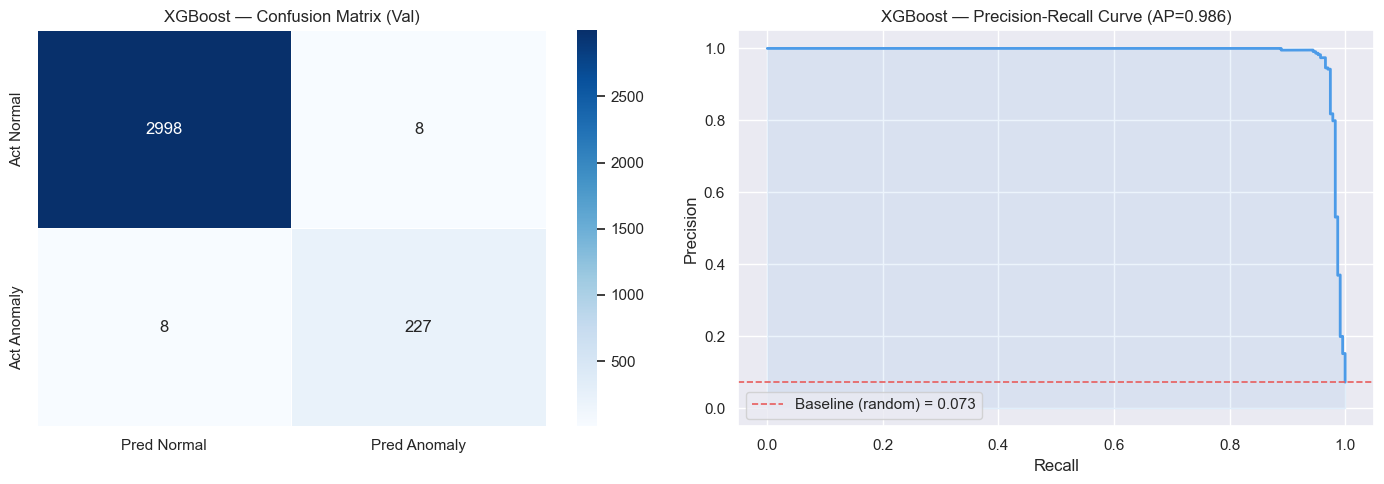


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3006
     Anomaly       0.97      0.97      0.97       235

    accuracy                           1.00      3241
   macro avg       0.98      0.98      0.98      3241
weighted avg       1.00      1.00      1.00      3241



In [17]:
best_name = results_df.iloc[0]["Model"]
best      = results[best_name]

print(f"Best model: {best_name}")
print(f"F1={best['f1']}  Precision={best['precision']}  "
      f"Recall={best['recall']}  ROC-AUC={best['roc_auc']}\n")

# Confusion matrix
cm = confusion_matrix(y_val, best['y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Anomaly'],
            yticklabels=['Act Normal', 'Act Anomaly'],
            linewidths=0.5)
axes[0].set_title(f'{best_name} — Confusion Matrix (Val)')

# Precision-Recall curve
prec_arr, rec_arr, _ = precision_recall_curve(y_val, best['y_proba'])
ap = best['avg_prec']
axes[1].plot(rec_arr, prec_arr, color='#4C9BE8', linewidth=2)
axes[1].fill_between(rec_arr, prec_arr, alpha=0.1, color='#4C9BE8')
axes[1].axhline(y=y_val.mean(), color='#E85D5D', linestyle='--',
                linewidth=1.2, label=f'Baseline (random) = {y_val.mean():.3f}')
axes[1].set_title(f'{best_name} — Precision-Recall Curve (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, best['y_pred'],
                             target_names=['Normal', 'Anomaly']))

In [18]:
best_clf = best['model']

# Final test set evaluation
y_test_pred  = best_clf.predict(X_test_scaled)
y_test_proba = best_clf.predict_proba(X_test_scaled)[:, 1]

test_f1      = f1_score(y_test, y_test_pred)
test_roc     = roc_auc_score(y_test, y_test_proba)
test_prec    = precision_score(y_test, y_test_pred)
test_rec     = recall_score(y_test, y_test_pred)

print("=" * 45)
print(f"FINAL TEST SET RESULTS — {best_name}")
print("=" * 45)
print(f"F1 Score  : {test_f1:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"ROC-AUC   : {test_roc:.4f}")

print(f"\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred,
                             target_names=['Normal', 'Anomaly']))

# Save best classifier
joblib.dump(best_clf, MODELS_DIR / "classifier_best.pkl")
print(f"\nBest classifier saved: {MODELS_DIR / 'classifier_best.pkl'}")
print(f"Model: {best_name}")

FINAL TEST SET RESULTS — XGBoost
F1 Score  : 0.9310
Precision : 0.9515
Recall    : 0.9114
ROC-AUC   : 0.9936

Classification Report (Test):
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      3003
     Anomaly       0.95      0.91      0.93       237

    accuracy                           0.99      3240
   macro avg       0.97      0.95      0.96      3240
weighted avg       0.99      0.99      0.99      3240


Best classifier saved: D:\B.TECH\Projects\cloud-anomaly-detector\models\classifier_best.pkl
Model: XGBoost


In [19]:
print("=" * 45)
print("NOTEBOOK 04 COMPLETE")
print("=" * 45)
print(f"Models trained       : {len(classifiers)}")
print(f"Best model           : {best_name}")
print(f"Best val F1          : {best['f1']}")
print(f"Best val ROC-AUC     : {best['roc_auc']}")
print(f"Test F1              : {test_f1:.4f}")
print(f"Artifacts saved      : classifier_best.pkl, scaler.pkl, feature_columns.json")
print(f"\nView MLflow UI:")
print(f"  Run in terminal: mlflow ui")
print(f"  Open: http://127.0.0.1:5000")
print(f"\nNext → 05_model_regression.ipynb")

NOTEBOOK 04 COMPLETE
Models trained       : 10
Best model           : XGBoost
Best val F1          : 0.966
Best val ROC-AUC     : 0.9957
Test F1              : 0.9310
Artifacts saved      : classifier_best.pkl, scaler.pkl, feature_columns.json

View MLflow UI:
  Run in terminal: mlflow ui
  Open: http://127.0.0.1:5000

Next → 05_model_regression.ipynb


In [20]:
# XGBoost had best ROC-AUC — tune its threshold
xgb_result = results["XGBoost"]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = []

for thresh in thresholds:
    y_pred_t = (xgb_result['y_proba'] >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1_val = max(f1_scores)

print(f"XGBoost optimal threshold : {best_thresh:.2f}")
print(f"XGBoost val F1 at threshold: {best_f1_val:.4f}")

# Apply to test
xgb_clf      = xgb_result['model']
y_test_proba_xgb  = xgb_clf.predict_proba(X_test_scaled)[:, 1]
y_test_pred_tuned = (y_test_proba_xgb >= best_thresh).astype(int)

test_f1_tuned = f1_score(y_test, y_test_pred_tuned)
test_roc_tuned = roc_auc_score(y_test, y_test_proba_xgb)

print(f"\nXGBoost Test F1 (default 0.5 threshold) : {f1_score(y_test, xgb_clf.predict(X_test_scaled)):.4f}")
print(f"XGBoost Test F1 (tuned threshold)       : {test_f1_tuned:.4f}")
print(f"XGBoost Test ROC-AUC                    : {test_roc_tuned:.4f}")

print(f"\n{classification_report(y_test, y_test_pred_tuned, target_names=['Normal','Anomaly'])}")

XGBoost optimal threshold : 0.55
XGBoost val F1 at threshold: 0.9701

XGBoost Test F1 (default 0.5 threshold) : 0.9310
XGBoost Test F1 (tuned threshold)       : 0.9348
XGBoost Test ROC-AUC                    : 0.9936

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      3003
     Anomaly       0.96      0.91      0.93       237

    accuracy                           0.99      3240
   macro avg       0.98      0.95      0.96      3240
weighted avg       0.99      0.99      0.99      3240



In [21]:
# Compare Extra Trees test F1 vs XGBoost tuned test F1
et_test_f1  = test_f1        # from cell 13
xgb_test_f1 = test_f1_tuned  # from cell 15

print(f"Extra Trees test F1  : {et_test_f1:.4f}")
print(f"XGBoost tuned test F1: {xgb_test_f1:.4f}")

# Save whichever is better on TEST set (not val set)
if xgb_test_f1 > et_test_f1:
    final_clf    = xgb_clf
    final_name   = "XGBoost (threshold tuned)"
    final_thresh = best_thresh
    print(f"\nWinner: XGBoost with threshold={best_thresh:.2f}")
else:
    final_clf    = best_clf
    final_name   = "Extra Trees"
    final_thresh = 0.5
    print(f"\nWinner: Extra Trees with threshold=0.50")

joblib.dump(final_clf, MODELS_DIR / "classifier_best.pkl")

# Save threshold too
import json
thresh_data = {"model": final_name, "threshold": float(final_thresh)}
with open(MODELS_DIR / "classifier_threshold.json", "w") as f:
    json.dump(thresh_data, f)

print(f"Saved: classifier_best.pkl")
print(f"Saved: classifier_threshold.json")
print(f"\nFinal classifier: {final_name}")

Extra Trees test F1  : 0.9310
XGBoost tuned test F1: 0.9348

Winner: XGBoost with threshold=0.55
Saved: classifier_best.pkl
Saved: classifier_threshold.json

Final classifier: XGBoost (threshold tuned)


In [22]:
df_check = pd.read_csv(DATA_PROCESSED / "cloud_metrics_featured.csv")
n = len(df_check)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Check what resource_id_enc values appear in each split
# (we dropped resource_id string but kept encoded version)
print("Train resource_id_enc unique:", 
      sorted(df_check.iloc[:train_end]['resource_id_enc'].unique()))
print("Val resource_id_enc unique:", 
      sorted(df_check.iloc[train_end:val_end]['resource_id_enc'].unique()))
print("Test resource_id_enc unique:", 
      sorted(df_check.iloc[val_end:]['resource_id_enc'].unique()))

print(f"\nTotal rows: {n}")
print(f"Train ends at row: {train_end}")
print(f"Val ends at row: {val_end}")
print(f"\nRows per resource: {n // 10}")
print(f"Train covers: {train_end / (n//10):.1f} resources worth of data")

Train resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Val resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test resource_id_enc unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Total rows: 21600
Train ends at row: 15119
Val ends at row: 18360

Rows per resource: 2160
Train covers: 7.0 resources worth of data
